In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
from MSTOkG.MSTOOpt import *
from joblib import Parallel, delayed
import sys

ERROR! Session/line number was not unique in database. History logging moved to new session 700


In [7]:
dirname = "./testdata/"
prefix = 'MOBS'

In [8]:
# choose your element
element = 'H'
# get the default molecule in your basis
mol = moldict('sto-2g')[element]
# print the energy (HF and FCI)
Nmax = 10
# facs = [np.random.random(), 0]
tol = 1e-16
itermax=10
print(getEnergies(mol))


{'HF': np.float64(-0.4543974016476272), 'FCI': array([-0.4543974]), 'CISD': np.float64(-0.4543974016476272), 'mol_HF': <pyscf.scf.rohf.HF1e object at 0x10d7a9640>, 'mol_FCI': <pyscf.fci.FCI.<locals>.CISolver object at 0x12862a120>, 'mol_cisd': <pyscf.ci.ucisd.UCISD object at 0x11018a6c0>}


In [9]:
for k in range(7, 12):
    print(f"k={k}")
    mol = FetchBestMol(element, k, dirname=dirname)['mol_FCI'].mol
    fname = os.path.join(dirname, f"{prefix}_{element}_msto-{k:02d}g.pickle")
    pop2, gen, en = OptimizeElement(mol, Nmax, fname, trials=20, tol=1e-16, trials_mu=15, trials_co=20, itermax=15)
    # pl.plot(gen, en, label=f"[{element}] msto-{k}g")
    mol = pop2[0][1]
    print()

k=7
[i:   19; M:    2; C:   19] Best: -0.49920705786457376 Ha, facs=[5.16187809874425e-10, 0]]]
k=8
[i:   19; M:    2; C:   19] Best: -0.49968541288482005 Ha, facs=[9.67940779372109e-10, 0]]]
k=9
[i:   19; M:    2; C:   19] Best: -0.4995877347685279 Ha, facs=[8.818928069053417e-10, 0]]
k=10
[i:   19; M:    2; C:   19] Best: -0.4996356848550108 Ha, facs=[6.602964590781732e-10, 0]]]
k=11
[i:   19; M:    2; C:   19] Best: -0.4997066042527155 Ha, facs=[7.011072548738573e-11, 0]]


In [5]:
# def FetchBestMol(element, k, dirname='./'):
#     try:
#         basis = f"sto-{k}g"
#         mol = loadBSI(os.path.join(dirname, f"BS_{element}_{basis}.pickle"))
#         try:
#             basis = f"msto-{k:02d}g"
#             mol = loadBSI(os.path.join(dirname, f"BS_{element}_{basis}.pickle"))
#         except:
#             mol = FetchBestMol(element, k-1)
        
#     except:
#         pass
#     return mol

# def DumpStandardBasis(element, basis, dirname='./'):
#     mol = moldict(basis)[element]
#     dumpBSI(deepcopy(getEnergies(mol)), fname=os.path.join(dirname,f"BS_{element}_{basis}.pickle"))
    

In [8]:
# for element in 'H Li Be B C N O F H2 LiH HF'.split(' '):
#     for k in range(2, 7):
#         basis = f"sto-{k}g"
#         try: 
#             print(f"    :   {element} {basis}", end='\r', flush=True)
#             DumpStandardBasis(element, basis, dirname=dirname)
#             print(f"Done:   {element} {basis}")
#         except:
#             print(f"Failed: {element} {basis}")
#     for basis in ['6-31g', 'ccpvdz']:
#         try: 
#             print(f"    :   {element} {basis}", end='\r', flush=True)
#             DumpStandardBasis(element, basis, dirname=dirname)
#             print(f"Done:   {element} {basis}")
#         except:
#             print(f"Failed: {element} {basis}")

In [16]:
# plotting the energies
element = 'H'
PrintEnergies(element, dirname = "./testdata/", table=True, plot=False, prefix="MOBS", 
              save=False, ylim=None)


# element = 'H2'
# k = 2
# mol = FetchBestMol(element, k, dirname=dirname)

# mol = moldict('sto-2g')[element]
# # print the energy (HF and FCI)
# Nmax = 10
# # facs = [np.random.random(), 0]
# tol = 1e-16
# itermax=10
# print(getEnergies(mol))

Element: H (Last update: 2025-15-10/13/25  15:15)
+--------+----------------------+----------------------+----------------------+
| Basis  | HF                   | FCI                  | CISD                 |
+--------+----------------------+----------------------+----------------------+
| 6-31g  | -0.49823291072907006 | -0.49823291072907017 | -0.49823291072907006 |
+--------+----------------------+----------------------+----------------------+
| ccpvdz | -0.49927840341958307 | -0.49927840341958324 | -0.49927840341958285 |
+--------+----------------------+----------------------+----------------------+
+----+----------------------+----------------------+----------------------+----------------------+----------------------+----------------------+
| k  | HF (STO)             | HF (MSTO)            | FCI (STO)            | FCI (MSTO)           | CISD (STO)           | CISD (MSTO)          |
+----+----------------------+----------------------+----------------------+----------------------+--

In [14]:
k = 3
BSI1= loadBSI(os.path.join(dirname, f"MOBS_{element}_msto-{k:02d}g.pickle"))
BSI1

{'HF': np.float64(-0.2542110562207498),
 'FCI': array([-0.25421106]),
 'CISD': np.float64(-0.2542110562207498),
 'mol_HF': <pyscf.scf.rohf.HF1e at 0x12e6fb5f0>,
 'mol_FCI': <pyscf.fci.FCI.<locals>.CISolver at 0x12e6faa80>,
 'mol_cisd': <pyscf.ci.ucisd.UCISD at 0x12e6fae40>}

In [8]:
# choose your element
element = 'H2'
# get the default molecule in your basis
mol = moldict('sto-6g')[element]
# print the energy (HF and FCI)
Nmax = 10
# facs = [np.random.random(), 0]
tol = 1e-16
itermax=10
print(getEnergies(mol))
mol = BasisReshape(mol, 8)

pop2, gen, en = OptimizeElement(mol, Nmax, trials=10, tol=1e-16, trials_mu=10, trials_co=10, itermax=10)

{'HF': np.float64(-1.1256286684274386), 'FCI': array([-1.14597785, -0.53276942, -0.17033333,  0.48819411]), 'CCSD': np.float64(-1.1459780117718037), 'mol_HF': <pyscf.scf.hf.RHF object at 0x70b3ac8732f0>, 'mol_FCI': <pyscf.fci.FCI.<locals>.CISolver object at 0x70b3b34b1940>, 'mol_ccsd': <pyscf.cc.ccsd.CCSD object at 0x70b3b3637490>}
[i:    9; M:    2; C:    9] Best: -1.1474902445225066 Ha, facs=[2.2067011080005527e-11, 0]

In [129]:



# for i in range(itermax):
#     iters=0
#     err = 1e9
    
#     while err>tol and iters<itermax:
#         iters = iters+1
#         j=0
#         # generate the initial population
#         pop2 = GenerateInitialPopulation(deepcopy(pop2[0][1]), 5*Nmax, facs)
#         # sort them by energies
#         pop2 = sorted(pop2, key=lambda x:x[0])[:Nmax]

#         facs = [np.random.random()/10**(i%10), 0]
#         pop2 = sorted(pop2+Mutate_v2(pop2, facs), key=lambda x:x[0])[:Nmax]
#         print(f"[i: {i:4d}; M:{iters:5d}; C:{j:5d}] Best: {pop2[0][0]} Ha, facs={facs}", flush=True, end='\r')
#         iters = iters+1
#         gen.append(iters)
#         en.append(pop2[0][0])
#         for j in range(itermax):
#             pop2 = sorted(pop2+CrossOvers(pop2), key=lambda x:x[0])[:Nmax]
#             print(f"[i: {i:4d}; M:{iters:5d}; C:{j:5d}] Best: {pop2[0][0]} Ha, facs={facs}", flush=True, end='\r')
#         iters = iters+1
#         gen.append(iters)
#         en.append(pop2[0][0])
        
#         # gen.append(iters)
#         # en.append(pop2[0][0])
        
#         err = np.abs(pop2[0][0]-pop2[-1][0])
# pop2

[i:    9; M:   11; C:    9] Best: -0.49817939376517106 Ha, facs=[6.401327157782302e-10, 0]]

[[np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd83110>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd83ed0>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd82710>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd83d90>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd834d0>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd825d0>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd83b10>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd82fd0>],
 [np.float64(-0.49817939376517106), <pyscf.gto.mole.Mole at 0x71cdfbd839d0>],
 [np.float64(-0.4981782012828574), <pyscf.gto.mole.Mole at 0x71cdfbd82990>]]

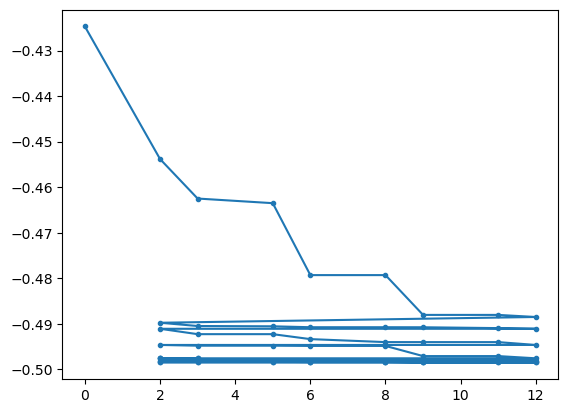

In [143]:
pl.plot(gen, en, '.-')
# pl.ylim([-0.5, -0.49])

In [123]:
mol = deepcopy(pop[0][1])
mol = BasisReshape(mol, 3)
pop, gen, en = OptimizeElement(mol, Nmax, facs, trials=10, tol=1e-10, trials_co=10, itermax=3)
pl.plot(gen, en, '.')

[M] Best: -0.498163911873184 Ha, facs=[9.918501090877881e-05, 0]]

KeyboardInterrupt: 

In [16]:


facs = [np.random.random(), 0]

pop = [[deepcopy(getEnergies(mol)['FCI'][0]), deepcopy(mol)]]
for i in range(Nmax-1):
    facs = [np.random.random(), 0]
    mol1 = dmol(mol, *facs)
    pop.append([deepcopy(getEnergies(mol1)['FCI'][0]), deepcopy(mol1)])
# each row has the structure [<energy>, <mol object>]. 
pop = sorted(pop, key=lambda x:x[0])



Text(0, 0.5, 'Energy (Ha)')

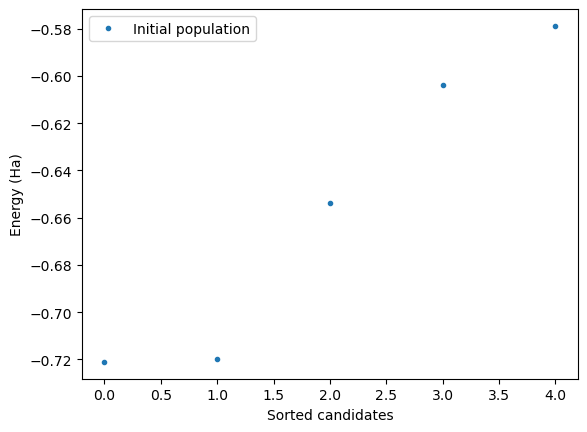

In [18]:
pl.plot([i[0] for i in pop], '.', label="Initial population")
pl.legend()
pl.xlabel('Sorted candidates')
pl.ylabel('Energy (Ha)')

Text(0, 0.5, 'Energy (Ha)')

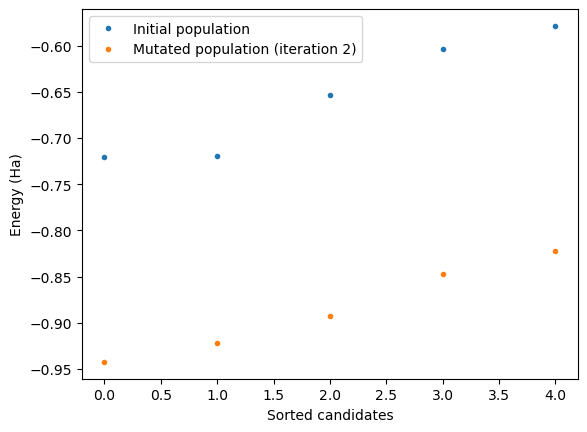

In [21]:
# let's repeat
facs = [np.random.random(), 0]
pop2 = Mutate(pop, facs)
pop2 = sorted(pop2, key=lambda x:x[0])

pl.plot([i[0] for i in pop], '.', label="Initial population")
pl.plot([i[0] for i in pop2], '.', label="Mutated population (iteration 2)")
pl.legend()
pl.xlabel('Sorted candidates')
pl.ylabel('Energy (Ha)')

Text(0, 0.5, 'Energy (Ha)')

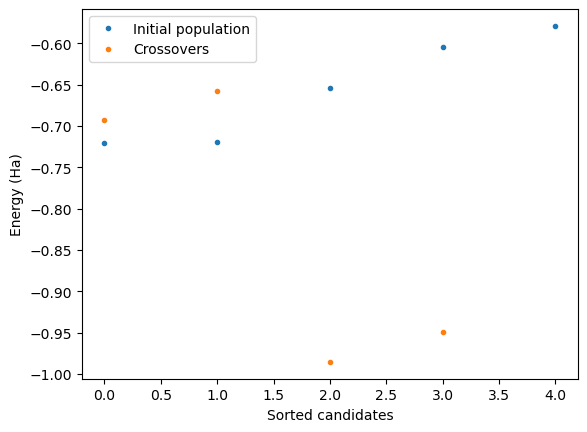

In [22]:
# do crossovers help?

cpop1 = CrossOvers(pop)
pl.plot([i[0] for i in pop], '.', label="Initial population")
pl.plot([i[0] for i in cpop1], '.', label="Crossovers")

pl.legend()
pl.xlabel('Sorted candidates')
pl.ylabel('Energy (Ha)')
# few are better but not as remarkable as mutations

In [23]:
# # repeating mutations
# # let's repeat

# pl.plot([i[0] for i in pop], '.', label="Initial")

# # facs = [int(''.join(np.random.choice(list('0123456789ABCDEF'),2)),16)/10**(3), 0]
# facs = [np.random.random(), 0]
# pop2 = sorted(pop + Mutate(pop, facs), key=lambda x:x[0])[:Nmax]
# i = 0
# for j in range(1):
#     facs = [np.random.random()/10**j, 0]
#     pop2 = sorted(pop2+Mutate(pop2, facs), key=lambda x:x[0])[:Nmax]
#     i=i+1
#     print(f"[M] Best: {pop2[0][0]} Ha, facs={facs}", flush=True, end='\r')
#     pl.plot([i[0] for i in pop2], '.', label=f"Mutated (gen {i})")
#     while np.abs(pop2[0][0]-pop2[-1][0])>1e-10:
#         # facs = [int(''.join(np.random.choice(list('0123456789ABCDEF'),j+2)),16)/10**(3+j), 0]
#         facs = [np.random.random()/10**j, 0]
#         pop2 = sorted(pop2+Mutate(pop2, facs), key=lambda x:x[0])[:Nmax]
#         i=i+1
#         print(f"[M] Best: {pop2[0][0]} Ha, facs={facs}", flush=True, end='\r')
#         pl.plot([i[0] for i in pop2], '.', label=f"Mutated (gen {i})")




# pl.legend()
# pl.xlabel('Sorted candidates')
# pl.ylabel('Energy (Ha)')

[C] Best: -1.0887807518140935 Ha, facs=[0.36430678142659356, 0]]

Text(0, 0.5, 'Energy (Ha)')

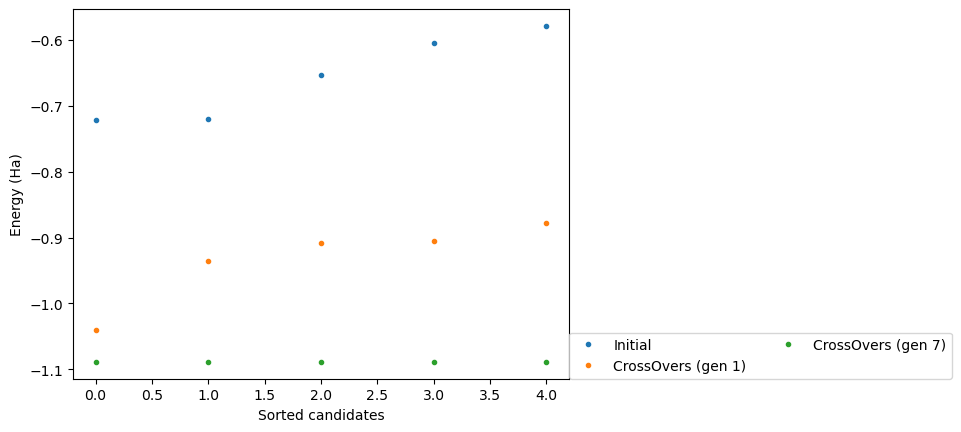

In [24]:
# repeating crossovers
# let's repeat

pl.plot([i[0] for i in pop], '.', label="Initial")

# facs = [int(''.join(np.random.choice(list('0123456789ABCDEF'),2)),16)/10**(3), 0]
facs = [np.random.random(), 0]
pop2 = sorted(pop + CrossOvers(pop), key=lambda x:x[0])[:Nmax]
i = 0
for j in range(1):
    facs = [np.random.random()/10**j, 0]
    pop2 = sorted(pop2+CrossOvers(pop2), key=lambda x:x[0])[:Nmax]
    i=i+1
    print(f"[C] Best: {pop2[0][0]} Ha, facs={facs}", flush=True, end='\r')
    pl.plot([i[0] for i in pop2], '.', label=f"CrossOvers (gen {i})")
    its = 0
    while np.abs(pop2[0][0]-pop2[-1][0])>1e-10 and its<100:
        its = its+1
        # facs = [int(''.join(np.random.choice(list('0123456789ABCDEF'),j+2)),16)/10**(3+j), 0]
        facs = [np.random.random()/10**j, 0]
        pop2 = sorted(pop2+CrossOvers(pop2), key=lambda x:x[0])[:Nmax]
        i=i+1
        print(f"[C] Best: {pop2[0][0]} Ha, facs={facs}", flush=True, end='\r')
    pl.plot([i[0] for i in pop2], '.', label=f"CrossOvers (gen {i})")




pl.legend(loc=(1,0), ncol=2)
pl.xlabel('Sorted candidates')
pl.ylabel('Energy (Ha)')

[M] Best: -1.136633607145225 Ha, facs=[6.337709062165381e-10, 0]]

/tmp/ipykernel_195904/595511243.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pl.legend(loc=(1,0), ncol=2)


Text(0, 0.5, 'Energy (best) [Ha] ')

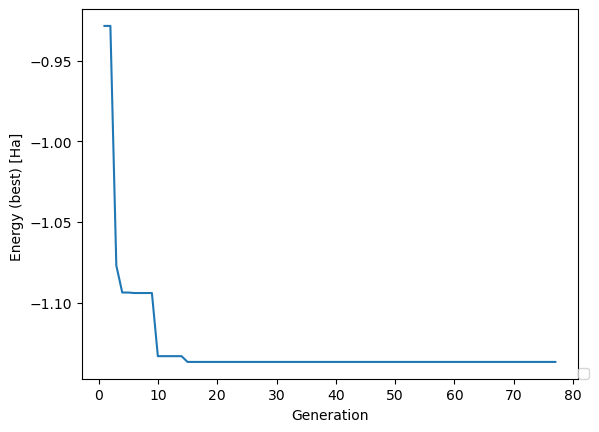

In [29]:
# crossovers followed by mutation

gen = []
en = []

# pl.plot([i[0] for i in pop], '.', label="Initial")

# facs = [int(''.join(np.random.choice(list('0123456789ABCDEF'),2)),16)/10**(3), 0]
facs = [np.random.random(), 0]
pop2 = sorted(pop + CrossOvers(pop), key=lambda x:x[0])[:Nmax]
i = 0
for j in range(10):
    facs = [np.random.random()/10**j, 0]
    pop2 = sorted(pop2+CrossOvers(pop2), key=lambda x:x[0])[:Nmax]
    i=i+1
    gen.append(i)
    en.append(pop2[0][0])
    print(f"[C] Best: {en[-1]} Ha, facs={facs}", flush=True, end='\r')
    # pl.plot([i[0] for i in pop2], '.', label=f"CrossOvers (gen {i})")
    for k in range(5):
        its = 0
        while np.abs(pop2[0][0]-pop2[-1][0])>1e-10 and its<100:
            its = its+1
            # facs = [int(''.join(np.random.choice(list('0123456789ABCDEF'),j+2)),16)/10**(3+j), 0]
            facs = [np.random.random()/10**j, 0]
            pop2 = sorted(pop2+CrossOvers(pop2), key=lambda x:x[0])[:Nmax]
            i=i+1
            gen.append(i)
            en.append(pop2[0][0])
            print(f"[C] Best: {en[-1]} Ha, facs={facs}", flush=True, end='\r')
        # pl.plot([a[0] for a in pop2], 'x', label=f"CrossOvers (gen {i})")
        facs = [np.random.random()/10**j, 0]
        pop2 = sorted(pop2+Mutate(pop2, facs), key=lambda x:x[0])[:Nmax]
        i=i+1
        gen.append(i)
        en.append(pop2[0][0])
        print(f"[M] Best: {en[-1]} Ha, facs={facs}", flush=True, end='\r')
        # pl.plot([a[0] for a in pop2], '.', label=f"Mutated (gen {i})")



pl.plot(gen, en)
pl.legend(loc=(1,0), ncol=2)
pl.xlabel('Generation')
pl.ylabel('Energy (best) [Ha] ')

In [189]:
a.hex()

'0x1.3be76c8b43958p+0'

In [206]:
a.fromhex('0x0.3be76c8b43958p+0')

0.23399999999999999

In [235]:
a.fromhex(f"0x0.{'0'*np.random.randint(10)}{''.join(np.random.choice(list('0123456789abcdef'), 7))}p+0")

4.691904464948493e-07

In [223]:
np.random.randint(10)

2